# 資料分析

1. 資料讀取
- 載入 `data/df_clean.csv`
- 確認欄位與資料筆數

2. 探索性分析（EDA）

    2.1 基本統計
    - 計算 `Duration (minutes)` 的 mean、median、std、min、max
    - 輸出統計表格

    2.2 各災害種類的 Duration 統計
    - 以 `Cause` 為分組依據
    - 計算各類別的 mean、median、std、min、max
    - 輸出統計表格

    2.3 Cause 分布統計
    - 計算各 Cause 類別的筆數與佔比
    - 繪製圓餅圖

    2.4 Duration 直方圖
    - 以線性尺度繪製 Duration 直方圖，觀察主體分布
    - 以 log 尺度繪製 Duration 直方圖，觀察尾部行為

3. CCDF 計算與繪製
- 計算經驗 CCDF：對 Duration 排序後計算 P(X > x)
- 以 log-log 尺度繪製 CCDF
- 此圖為後續擬合比較的基準圖

4. Log-normal 分布擬合

    4.1 估計 μ、σ

    4.2 CCDF 比較圖
    - 在 3. 的 CCDF 圖上疊加 log-normal 擬合曲線
    - 視覺觀察擬合曲線與實際資料的偏離位置，初步判斷尾部開始不符合的區間

5. Log-normal 有效範圍搜尋

    5.1 Binary search + KS test (檢測資料是否符合某個分布的方法)
    - 搜尋範圍：`[log(duration 最小值), log(duration 最大值)]`（log 空間）
    - 每次取中點 `mid`，對 `duration ≤ exp(mid)` 的資料進行 KS test
        - p > 0.10 → 符合 log-normal，往右搜尋（`low = mid`）
        - p ≤ 0.10 → 不符合，往左搜尋（`high = mid`）
    - 收斂條件：`high - low < 1e-3`（log 空間容忍值）
    - 確保每次 KS test 的樣本數 ≥ 30


    5.2 截斷點結果 (後續改為說明與討論，本檢測方式我認為不適用於這個 case )

6. 相對誤差檢核

7. 結論與策略


# 1. 資料讀取

In [74]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "df_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：9481
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year', 'outage_year', 'threshold']


,Name,Out Datetime,In Datetime,Voltage (kV),Duration (minutes),Outage Type,Cause,year,outage_year,threshold
0,Napavine-Chehalis Power No 2 500kV line,2012-01-05 16:21:00,2012-01-05 20:49:00,500.0,268,Auto,Other,2012,{2012},49487.0
1,Napavine-Chehalis Power No 3 500kV line,2012-01-05 16:21:00,2012-01-05 20:49:00,500.0,268,Auto,Other,2012,{2012},49487.0
2,Napavine-Chehalis Power No 1 500kV line,2012-01-05 16:21:00,2012-01-08 19:33:00,500.0,4512,Auto,Other,2012,{2012},49487.0
3,Big Eddy-Celilo No 1 500kV line,2012-01-06 17:39:00,2012-01-06 19:16:00,500.0,97,Auto,Other,2012,{2012},49487.0
4,Big Eddy-Celilo No 3 230kV line,2012-01-06 17:39:00,2012-01-13 16:21:00,230.0,10002,Auto,Other,2012,{2012},49487.0


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄停電時間的 "平均值", "中位數", "標準差", "最小值", "最大值" 等資訊

* 可以看到中位數遠小於平均值的重尾現象，也就是具有極端事件影響導致平均復電時間較長

In [75]:
# 2.1 基本統計
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,528.71
Median,69.00
Std,2441.52
Min,1.00
Max,45280.00


## 2.2 損害原因與復電時間統計資料

In [76]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Foreign Trouble,364,443.62,113.0,978.72,1,6835
Lightning,973,271.86,9.0,1038.62,1,10737
Other,3165,439.64,46.0,2225.51,1,45280
Tree Blown,1292,854.69,197.0,3490.38,1,41547
Unknown,1604,399.59,47.0,2055.03,1,42656
Weather,1536,699.54,58.0,2685.16,1,43358
Wind,547,686.55,94.0,3192.17,1,34931


## 2.3 損害原因比例

* 可以看到 weather 的比例很高，但由於資料沒有明確說明 weather 是哪一類的氣候種類，推測高機率為閃電或是風造成的，這可能是人為的登記問題，總不可能有一堆的火災或是砂塵暴吧!

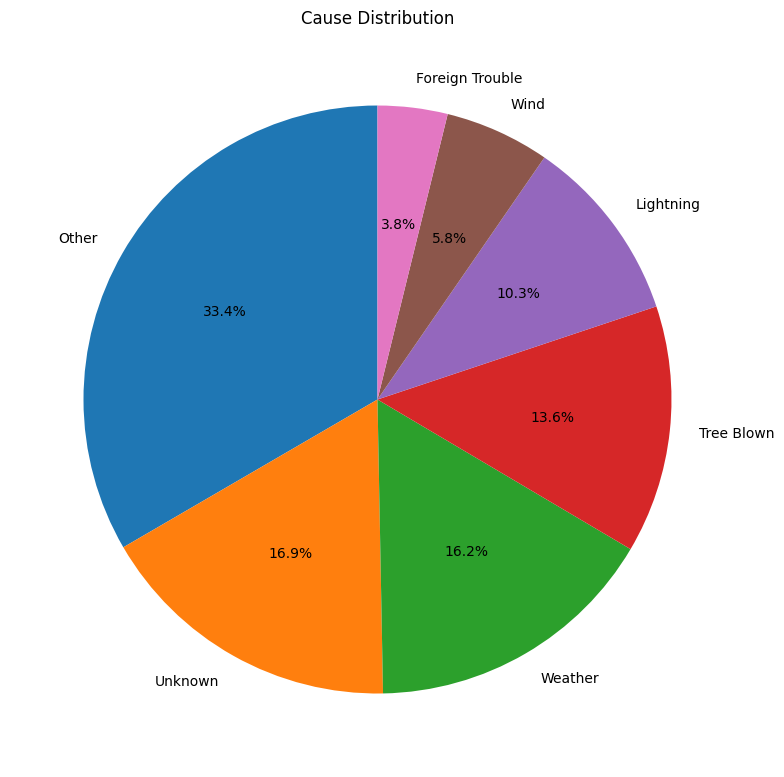

In [77]:
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

由於 wheather 的比例比我想像中高、確認一下是否有異常事件在某個年度發生

看起來並沒有大型的天氣災害事件

In [78]:
# 各年度 Cause 分布
year_cause = df.groupby(["year", "Cause"]).size().unstack(fill_value=0)
year_cause_pct = year_cause.div(year_cause.sum(axis=1), axis=0).round(3) * 100
year_cause_pct

Cause,Foreign Trouble,Lightning,Other,Tree Blown,Unknown,Weather,Wind
year,,,,,,,
2012,2.8,9.9,49.0,10.3,13.7,12.2,2.1
2013,4.0,15.7,56.0,1.2,10.5,6.8,5.8
2014,1.8,14.2,28.4,9.7,23.0,17.6,5.3
2015,3.9,5.7,25.3,14.5,17.3,17.9,15.4
2016,6.8,2.1,43.3,12.6,19.3,15.0,1.0
2017,1.9,10.7,28.8,6.8,27.7,16.0,8.0
2018,4.6,9.6,36.5,13.2,14.6,16.2,5.2
2019,5.5,15.0,26.7,24.2,8.8,16.8,3.0
2020,4.4,8.2,22.1,23.6,15.2,21.6,5.1


## 2.4 Duration 直方圖

1. 線性直方圖

2. Log 尺度下直方圖

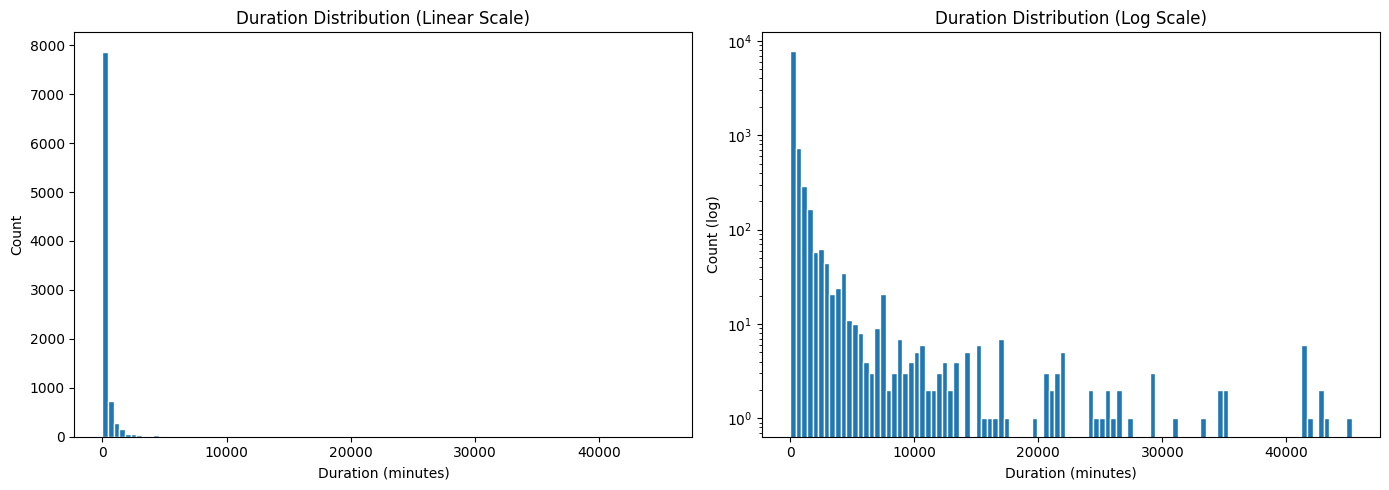

In [79]:
# 2.4 Duration 直方圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 線性尺度
axes[0].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[0].set_title("Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log 尺度
axes[1].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

# 3. CCDF 計算與繪製

* 目的 : 計算並繪製修復時間的經驗互補累積分布函數（CCDF），以 log-log 尺度呈現。若分布具有重尾特性，資料點在 log-log 圖上會呈現近似線性的行為。此圖將作為後續 log-normal 擬合比較的基準。

* 橫軸 : 修復時間（分鐘），以 log 尺度呈現，範圍從 1 分鐘到數萬分鐘，跨越多個數量級。

* 縱軸 : P(X > x) 互補累積機率，即修復時間超過 x 分鐘的機率，以 log 尺度呈現。數值越小代表該修復時間越罕見。

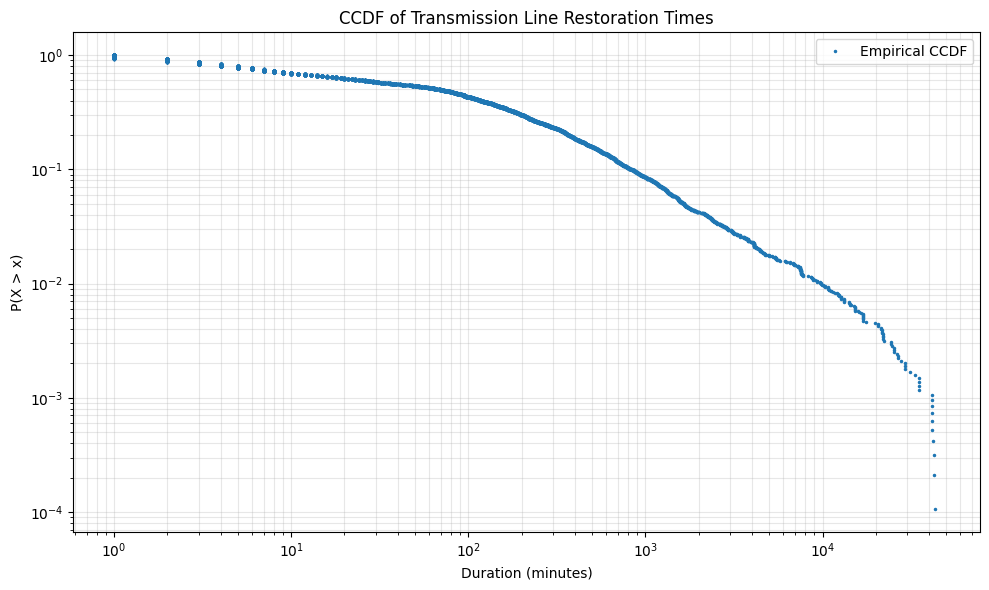

In [80]:
import numpy as np

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 發生該修復時間的互補累積機率 (1-累積機率)
# 使用 arange 將 numpy 陣列做 [1,2...] 排列，也就是記數
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
# 修復時間超過 x 分鐘的機率
plt.ylabel("P(X > x)")
plt.title("CCDF of Transmission Line Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 函式分布擬合

* 對修復時間資料進行多種機率分布擬合，透過最大概似估計法（Maximum Likelihood Estimation, MLE）估計各分布的參數，並以 AIC（Akaike Information Criterion）作為模型選擇依據。
  
  1. **MLE（最大概似估計法）**：透過最大化對數概似函數來估計分布參數，即尋找一組參數使得觀測資料出現的機率最大。
   
        $$\hat{\theta} = \arg\max_{\theta} \sum_{i=1}^{n} \ln f(x_i \mid \theta)$$
   
       * 簡單來說就是找參數去擬合出近似實際資料的線型
    
  2. **AIC（赤池資訊準則）**：在對數概似值的基礎上對參數數量 $k$ 進行懲罰，避免過度擬合，數值越小代表模型越佳。

        $$AIC = 2k - 2\ln(\hat{L})$$
   
       * AIC 的絕對數值本身沒有意義，它只有在跟其他模型比較時才有意義，通常以 ΔAIC（與最佳模型的差距）作為判斷依據。

            | ΔAIC | 解讀 |
            |------|------|
            | 0 ~ 2 | 與最佳模型幾乎無差異，都值得考慮 |
            | 2 ~ 6 | 有一定差距，次佳模型支持度較弱 |
            | 6 ~ 10 | 差距明顯，次佳模型支持度很弱 |
            | > 10 | 幾乎可以排除該模型 |

  3. **KS D 統計量**：衡量實際 CCDF 與理論 CCDF 之間的最大絕對誤差值，越小代表曲線與實際資料可能越接近，作為輔助視覺判斷的參考指標
   
        $$D=xmax​∣Fempirical​(x)−Ftheoretical​(x)∣$$

* 候選分布涵蓋 Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma 共六種，涵蓋右偏、重尾、廣義形式等不同特性，以確保比較的完整性。

  


## 4.1 函式擬合

In [81]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Candidate Distribution Fitting (MLE) + AIC + KS D
# 擬合函式候選者
candidates = {
    "Log-normal":  stats.lognorm,
    "Weibull":     stats.weibull_min,
    "Gamma":       stats.gamma,
    "Burr (XII)":  stats.burr,
    "Gen. Pareto": stats.genpareto,
    "Gen. Gamma":  stats.gengamma,
}

fit_results   = []
fitted_params = {}

for name, dist in candidates.items():
    try:
        # MLE 擬合：估計參數
        # 固定 floc=0 修復時間不可為負
        params  = dist.fit(duration_sorted, floc=0)

        # 計算每個資料點在當前參數下的對數機率密度，加總得到整批資料的總對數概似值
        log_lik = dist.logpdf(duration_sorted, *params).sum()

        # 若對數概似值非有限數（如 -inf），代表擬合失敗，跳過
        if not np.isfinite(log_lik):
            print(f"{name}: non-finite log-likelihood, skipped")
            continue

        # 自由參數數量：總參數數減 1（loc 已固定，不計入）
        k = len(params) - 1

        # AIC = 2k - 2 * ln(L)，k 為參數數，L 為最大概似值
        aic = 2 * k - 2 * log_lik

        # KS D 統計量：衡量實際 CCDF 與理論 CCDF 之間的最大絕對偏差
        ks_stat, _ = stats.kstest(duration_sorted, dist.cdf, args=params)

        # 將擬合成果寫入 list
        fit_results.append({
            "Distribution": name,
            "AIC"         : round(aic, 0),
            "KS D"        : round(ks_stat, 5),
            "params"      : params,
        })

        # 保存分布物件與參數，供後續 CCDF 繪圖使用
        fitted_params[name] = (dist, params)

    except Exception as e:
        print(f"{name} fit failed: {e}")

# 將擬合後資料依據 AIC 大小排序後寫入表格
results_df = pd.DataFrame(fit_results).sort_values("AIC").reset_index(drop=True)

# 計算 ΔAIC
results_df["ΔAIC"] = (results_df["AIC"] - results_df["AIC"].min()).round(0)

# Check
results_df[["Distribution", "AIC", "ΔAIC", "KS D"]]

,Distribution,AIC,ΔAIC,KS D
0,Log-normal,116368.0,0.0,0.07334
1,Gen. Gamma,116616.0,248.0,0.06740
2,Burr (XII),116947.0,579.0,0.09129
3,Gen. Pareto,117511.0,1143.0,0.11091
4,Weibull,117622.0,1254.0,0.10017
5,Gamma,120499.0,4131.0,0.13819


## 4.2 視覺化

* 擬合結果 : 
  
  * AIC 排名第一為 Log-normal，模型僅含 μ、σ 兩個參數，在簡潔性與擬合品質的綜合評估下表現最佳，亦與電力系統修復時間文獻中最常採用的分布一致。
  
  * KS D 排名第一為 Gen. Gamma ，但由於斷尾原因，後續處理時，可用區間貼合程度明顯不如前者

  * 尾段出現明顯的斷尾現象，主要原至於對異常值的切分，這是在處裡非搶修情況，當沒有標籤資料下勢必會遇到的問題，考量我們的研究著重在發生機率與修復時間上，後續處裡時會截掉明顯無法擬合的斷尾段，當後續低於發生機率低於一定值時，以最差情況模擬之

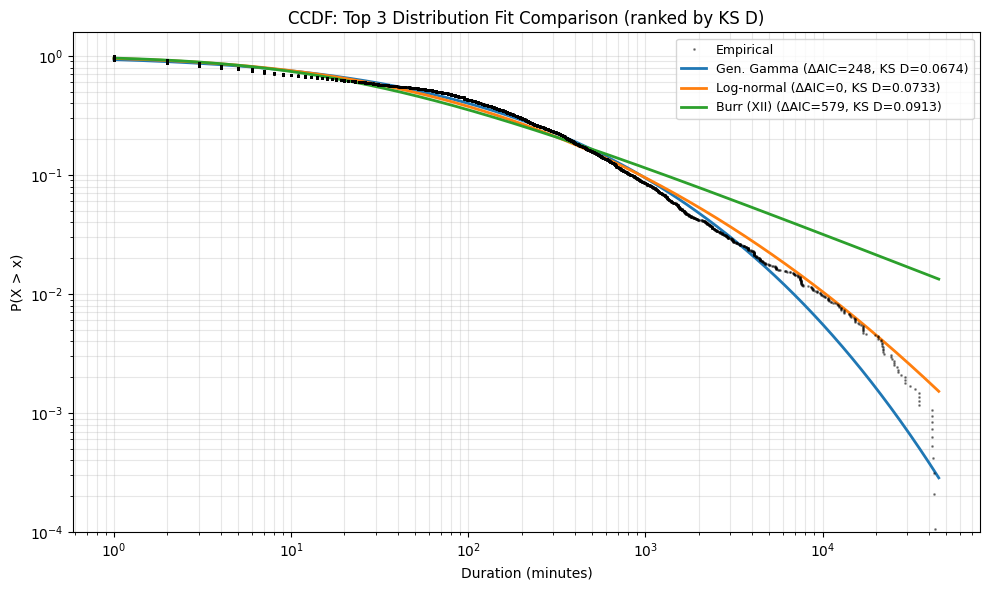

In [82]:
# CCDF Comparison — Top 3 by KS D (full range, log-log)
# 依 KS D 由小至大排序，取前三名（KS D 越小代表曲線與實際資料可能越接近）
top3   = results_df.sort_values("KS D").head(3)["Distribution"].tolist()
x_plot = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 600)
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(10, 6))

# 繪製實際資料的 CCDF
ax.loglog(duration_sorted, ccdf, "k.", markersize=2, alpha=0.4, label="Empirical", zorder=5)

# 依 KS D 排名取前三名，逐一繪製理論 CCDF 曲線
for name, color in zip(top3, colors):
    dist, params = fitted_params[name]

    # 計算理論 CCDF：1 - CDF
    ccdf_th = 1 - dist.cdf(x_plot, *params)

    row = results_df[results_df["Distribution"] == name].iloc[0]
    ax.loglog(x_plot, ccdf_th, linewidth=2, color=color,
              label=f'{name} (ΔAIC={row["ΔAIC"]:.0f}, KS D={row["KS D"]:.4f})')

ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF: Top 3 Distribution Fit Comparison (ranked by KS D)")
ax.set_ylim(bottom=1e-4)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 說明與討論

部分論文使用 KS Test（Kolmogorov-Smirnov Test）來檢核對數常態分佈是否擬合，擬合結果難以達成(可上 git branch 中看前版本)，說明如下

* 原理

    KS test 計算實際 CCDF 和理論 CCDF 之間的最大差距（D 統計量）：
    >
    >    D = max|F_empirical(x) - F_theoretical(x)|
    >
    >    D 越小代表實際資料與理論分布越接近。

* p-value 計算

    1. 算出 D 統計量
    2. 將 D 標準化：D* = D × (√n + 0.12 + 0.11/√n)
    3. 將 D* 帶入 KS 分布的累積函數，得到 p-value

p-value 的直觀意思為：在 KS 分佈中觀測到這麼大或更大的 D 值的機率。

- p > 0.10 → 無法拒絕「資料符合該分布」的假設
- p ≤ 0.10 → 拒絕，資料不符合該分布

> 為何不適用於本題目 : 這個測試怎麼可能適合重尾，方法將最大誤差放大(跟 n 成正比)之後去觀察 KS 分佈超越該誤差的機率，但對於重尾情況來說，等於缺資料的地方不準確，準確的地方資料多，資料多還會去放大缺資料的誤差

# 6. 相對誤差檢核

* 原理

    >對每個資料點 x，計算實際 CCDF 與 log-normal 理論 CCDF 之間的相對誤差：
    >
    >   Relative Error = |F_empirical(x) - F_theoretical(x)| / F_empirical(x) => |預測值 - 實際值| / 實際值

* 相較於 KS test 只取最大差距，相對誤差法考慮每個點的誤差大小，能更全面反映整體的擬合品質，且不受樣本數影響。

* 誤差判斷標準 : 一般而言，相對誤差的判斷標準如下
    >
    > 誤差 < 5%：擬合非常好
    >
    > 誤差 5% ~ 10%：擬合良好，可接受
    >
    > 誤差 10% ~ 20%：擬合尚可，需注意偏離區間
    >
    > 誤差 > 20%：擬合較差，分布假設可能不適用

* 本資料的結果：

  * 一般統計 : 
    1. 中位數相對誤差 7.54%：整體擬合良好
    2. 平均數相對誤差 8.28% : 平均 > 中位數，呈現重尾現象
    3. 最大相對誤差 1434.82%：尾部極端點嚴重偏離，反映重尾、斷尾資料的現象
  
  * 離散化統計 :
    1. 68.9% 的點位誤差 < 10%（非常好 + 良好合計），代表超過 2/3 的資料使用 Log-normal 分布進行估計都能有效描述
    2. 95.1% 的點位誤差 < 20%，也就是幾乎所有資料都在「尚可」以上
    3. 誤差 > 20% 的「偏差」點位僅佔 4.9%，且這些由後續視覺化可得知集中在尾部極端區段，但誤差大需做合理的假設

## 一般統計

In [83]:
# 相對誤差檢核
# Log-normal 全域擬合參數
params_global = stats.lognorm.fit(duration_sorted, floc=0)
sigma = params_global[0]
mu    = np.log(params_global[2])

# 計算實際 CCDF 與理論 CCDF
ccdf_empirical = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)
ccdf_lognorm   = 1 - stats.lognorm.cdf(duration_sorted, s=sigma, scale=np.exp(mu))

# 過濾掉 ccdf_empirical = 0 的點，避免分母為零
mask = ccdf_empirical > 0
ccdf_empirical_valid = ccdf_empirical[mask]
ccdf_lognorm_valid   = ccdf_lognorm[mask]

# 相對誤差：|實際 CCDF - 理論 CCDF| / 實際 CCDF
rel_err = np.abs(ccdf_empirical_valid - ccdf_lognorm_valid) / ccdf_empirical_valid

# 輸出各百分位誤差分布
print("── 相對誤差分布 ──")
print(f"中位數相對誤差: {np.median(rel_err)*100:.2f}%")
print(f"平均相對誤差: {np.mean(rel_err)*100:.2f}%")
print(f"最大相對誤差: {rel_err.max()*100:.2f}%")

── 相對誤差分布 ──
中位數相對誤差: 7.54%
平均相對誤差: 8.28%
最大相對誤差: 1434.82%


## 離散化統計

In [84]:
bins   = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, np.inf)]
labels = ["< 5%（非常好）", "5 ~ 10%（良好）", "10 ~ 20%（尚可）", "> 20%（偏差）"]
n_total    = len(rel_err)
cumulative = 0.0

rows = []
for (lo, hi), label in zip(bins, labels):
    cnt  = int(((rel_err >= lo) & (rel_err < hi)).sum())
    pct  = cnt / n_total * 100
    cumulative += pct
    rows.append({
        "誤差區間"  : label,
        "點數"      : cnt,
        "比例 (%)"  : round(pct, 1),
        "累積比例 (%)": round(cumulative, 1),
    })

err_table = pd.DataFrame(rows).set_index("誤差區間")

pct_10 = (rel_err < 0.10).mean() * 100
pct_20 = (rel_err < 0.20).mean() * 100

err_table

,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,3228,34.1,34.1
5 ~ 10%（良好）,3308,34.9,68.9
10 ~ 20%（尚可）,2479,26.1,95.1
> 20%（偏差）,465,4.9,100.0


## 視覺化

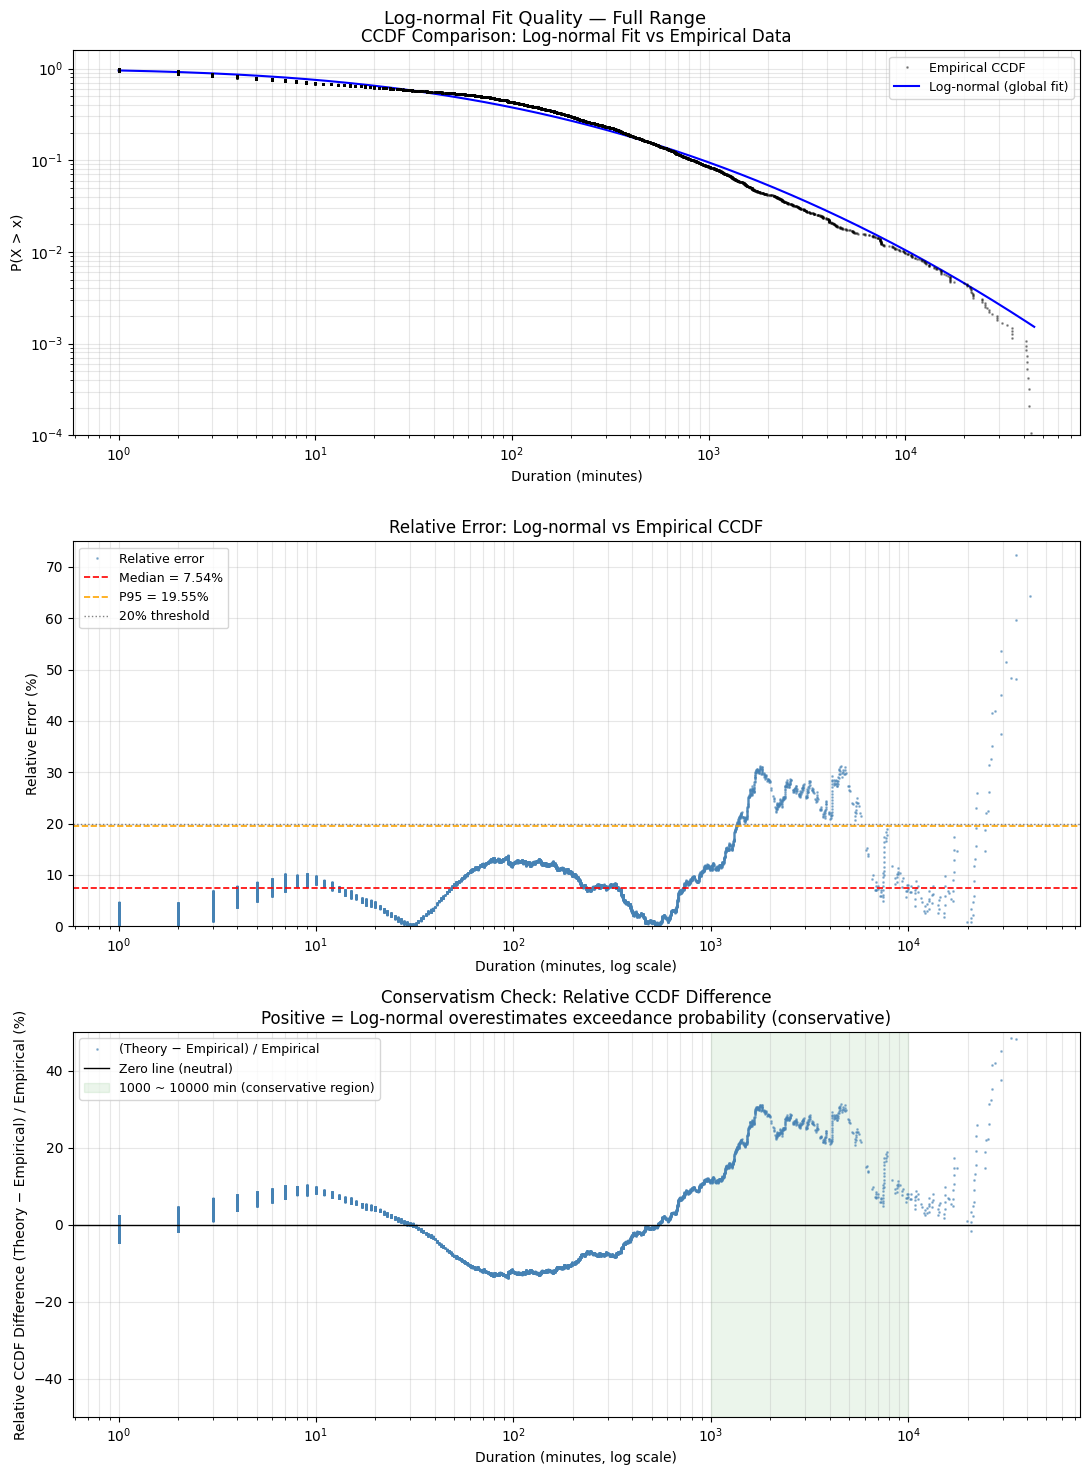

In [89]:
# ── 視覺化 ────────────────────────────────────────────────────
x_plot  = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 600)
ccdf_th = 1 - stats.lognorm.cdf(x_plot, *params_global)

fig, axes = plt.subplots(3, 1, figsize=(11, 15))
fig.suptitle("Log-normal Fit Quality — Full Range", fontsize=13)

# ── Plot 1: CCDF comparison ───────────────────────────────────
ax = axes[0]
ax.loglog(duration_sorted, ccdf_empirical, "k.", markersize=2,
          alpha=0.35, label="Empirical CCDF", zorder=5)
ax.loglog(x_plot, ccdf_th, "b-", linewidth=1.5, label="Log-normal (global fit)")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF Comparison: Log-normal Fit vs Empirical Data")
ax.set_ylim(bottom=1e-4)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# ── Plot 2: 相對誤差 vs duration ──────────────────────────────
x_valid = duration_sorted[mask]

ax = axes[1]
ax.semilogx(x_valid, rel_err * 100,
            ".", color="steelblue", markersize=2, alpha=0.5, label="Relative error")
ax.axhline(np.median(rel_err) * 100, color="red", linestyle="--",
           linewidth=1.2, label=f"Median = {np.median(rel_err)*100:.2f}%")
ax.axhline(np.percentile(rel_err, 95) * 100, color="orange", linestyle="--",
           linewidth=1.2, label=f"P95 = {np.percentile(rel_err, 95)*100:.2f}%")
ax.axhline(20, color="gray", linestyle=":", linewidth=1.0, label="20% threshold")
ax.set_ylim(0, 75)
ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Relative Error: Log-normal vs Empirical CCDF")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# ── Plot 3: 理論 − 實際 CCDF 相對差值（保守性佐證）──────────
ax = axes[2]

ccdf_th_data = 1 - stats.lognorm.cdf(duration_sorted, *params_global)
valid_p3     = ccdf_empirical > 0
rel_diff     = (ccdf_th_data[valid_p3] - ccdf_empirical[valid_p3]) / ccdf_empirical[valid_p3]

ax.semilogx(duration_sorted[valid_p3], rel_diff * 100, ".", color="steelblue",
            markersize=2, alpha=0.5, label="(Theory − Empirical) / Empirical")
ax.axhline(0, color="black", linewidth=1.0, linestyle="-", label="Zero line (neutral)")
ax.axvspan(1000, 10000, alpha=0.08, color="green",
           label="1000 ~ 10000 min (conservative region)")
ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Relative CCDF Difference (Theory − Empirical) / Empirical (%)")
ax.set_title("Conservatism Check: Relative CCDF Difference\n"
             "Positive = Log-normal overestimates exceedance probability (conservative)")
ax.set_ylim(-50, 50)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 7. 直接使用全域擬合之說明

* **不設擬合區間的理由**

    資料已於前處理階段以 **DOE-417 WECC 全域最大值（global_max）** 作為異常值截斷閾值，超過者直接移除。此步驟已剔除推測因替代供電而長期掛帳、不具搶修意義的紀錄。

    若在已清理的資料上再行設定擬合截斷點（如 P = 0.001 或 34 天）(前版本)，等同對同一批資料進行**二次人為限制**，實際效果如下：

    截去尾段 + 斷尾以 worst case 填補，擬合曲線在截斷點前視覺上看似變好，但截斷點後直接跳至最差情況，整體誤差反而增大 

* **結論**

    由於異常值已於前處理中移除，Log-normal 全域擬合結果可直接作為**修復時間－機率模擬**的基礎，無需額外設定擬合區間。後續將驗證此做法在整體期望值層面的保守性。



# 8. 保守設計驗證

* **誤差期望值**

* 驗證邏輯

    由於輸電線路災害為隨機事件，單一事件的估計值可能高估或低估，但可靠度評估真正關心的是**長期多次事件下的期望修復時間**。因此以下結果成立，則表示對數常態分佈估計值偏保守側：

    > 若 $\Delta E[T] > 0$，代表模型在各機率點的修復時間估計期望值偏向高估，模擬結果具保守性。

* 定義

    | 指標 | 計算方式 | 說明 |
    |------|----------|------|
    | 逐點誤差 $\Delta T_i$ | $x_{estimated}(p_i) - x_{empirical}(p_i)$ | 正值代表高估，負值代表低估 |
    | 誤差期望值 $\Delta E[T]$ | $\dfrac{1}{n}\sum_{i=1}^{n} \Delta T_i$ | 各事件誤差的算術平均，反映模擬的整體偏向 |
    | 相對高估比例 | $\dfrac{\Delta E[T]}{\bar{x}} \times 100\%$ | 相對於歷史平均修復時間的高估幅度 |


In [86]:
# 每個實際資料點對應的超越機率
p_i = ccdf_empirical[mask]

# 實際修復時間的算術平均
actual_mean = duration_sorted.mean()

# 在相同超越機率下，Log-normal 反查估計修復時間
x_empirical = duration_sorted[mask]
x_estimated = stats.lognorm.ppf(1 - p_i, s=sigma, scale=np.exp(mu))

# 逐點差值（估計 - 實際）
delta_T = x_estimated - x_empirical

# 等權重期望誤差
delta_E_T = delta_T.mean()
pct_delta = delta_E_T / actual_mean * 100

print(f"誤差期望值 ΔE[T] : {delta_E_T:+.2f} min  ({delta_E_T/60:+.4f} hr)")
print(f"相對高估比例 : {pct_delta:+.2f}%")
print(f"方向 : {'高估（保守）' if delta_E_T > 0 else '低估（非保守）'}")

誤差期望值 ΔE[T] : +130.01 min  (+2.1669 hr)
相對高估比例 : +24.59%
方向 : 高估（保守）
